## — PROJECT INTRODUCTION

# 🛒 Retail Sales & Profit Analytics System

## 📌 Project Overview
This project analyzes retail sales data to identify business insights related to:
- Sales
- Profit
- Customers
- Product categories
- Regions
- Shipping performance

## 🎯 Objectives
- Identify top-performing categories
- Find loss-making areas
- Analyze customer behavior
- Generate business recommendations

## 🛠️ Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## 👨‍💻 Author
Shitanshu Jayprakash Chaurasiya

## — IMPORT LIBRARIES

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


##  📂 Load Dataset

In [ ]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Data Cleaning

In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#df = df.drop_duplicates()

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [12]:
df['Delivery Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [13]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Delivery Time
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


## 💰 Sales Analysis

In [14]:
df['Sales'].sum()

np.float64(2297200.8603)

In [15]:
sales_by_category = df.groupby('Category')['Sales'].sum()

sales_by_category

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [16]:
sales_by_region = df.groupby('Region')['Sales'].sum()

sales_by_region

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

In [17]:

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

# 📈 Profit Analysis

In [18]:
df['Profit'].sum()

np.float64(286397.0217)

In [19]:
profit_by_category = df.groupby('Category')['Profit'].sum()

profit_by_category

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [20]:
profit_by_region = df.groupby('Region')['Profit'].sum()

profit_by_region

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

In [22]:
loss_subcategories = df.groupby('Sub-Category')['Profit'].sum().sort_values()

loss_subcategories

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

## 👥 Customer Analysis

In [23]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [24]:
top_profit_customers = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)

top_profit_customers

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

##  🚚 Shipping Analysis

In [25]:
df['Delivery Time'].mean()

np.float64(3.958174904942966)

In [26]:
df.groupby('Ship Mode')['Delivery Time'].mean()

Ship Mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006535
Name: Delivery Time, dtype: float64

# 📊 Data Visualizations

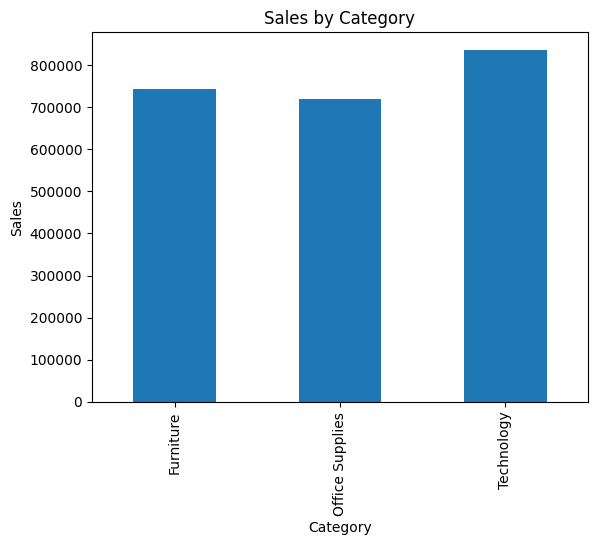

In [27]:
sales_by_category.plot(kind='bar')
plt.title('Sales by Category')
plt.ylabel('Sales')
plt.show()

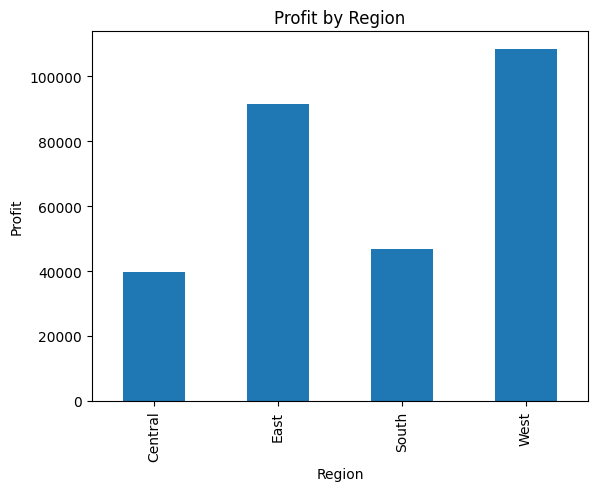

In [28]:
profit_by_region.plot(kind='bar')
plt.title('Profit by Region')
plt.ylabel('Profit')
plt.show()

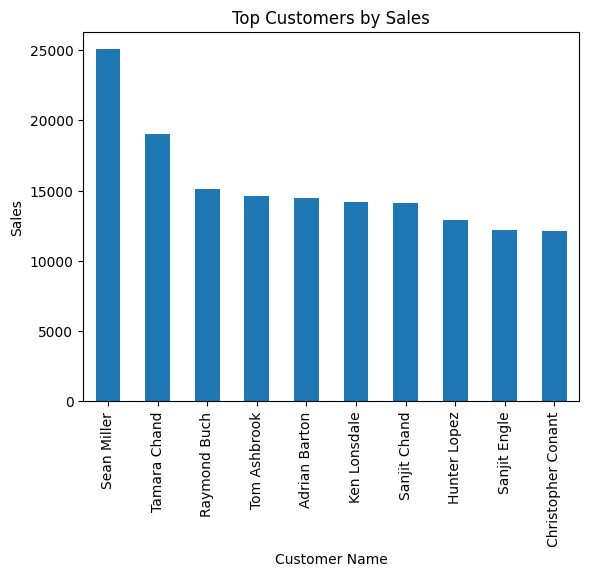

In [29]:
top_customers.plot(kind='bar')
plt.title('Top Customers by Sales')
plt.ylabel('Sales')
plt.show()

# 💡 Business Insights

## Key Findings

- Technology category generates highest sales.
- Some furniture products create losses despite strong sales.
- Western region contributes highest profit.
- Delivery time impacts customer experience.
- A small set of customers contributes major revenue.

## Recommendations

- Focus more on profitable product categories.
- Reduce discounts on loss-making products.
- Improve shipping efficiency.
- Target high-value customers with loyalty programs.

In [40]:
df.to_csv('../data/cleaned_superstore.csv', index=False)

# 🗄️ PostgreSQL Database Integration

In [31]:
from sqlalchemy import create_engine

In [32]:
engine = create_engine('postgresql://localhost/retail_sales')

In [33]:
df.to_sql(
    'sales_data',
    con=engine,
    if_exists='replace',
    index=False
)

994

# 📊 Business Visualizations

In [ ]:
import matplotlib.pyplot as plt

In [34]:
plt.style.use('ggplot')

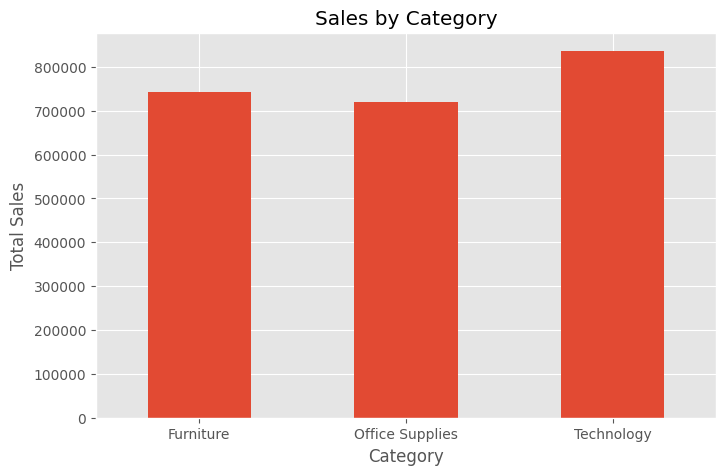

In [36]:
sales_by_category = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))

sales_by_category.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)

plt.savefig('../screenshots/sales_by_category.png')

plt.show()

## 1. Sales by Category

Technology generated the highest total sales among all categories.

This indicates strong customer demand for technology-related products and suggests that the business should continue investing in high-performing technology products.

Furniture and Office Supplies also contributed significantly to revenue, but their sales were lower compared to Technology.

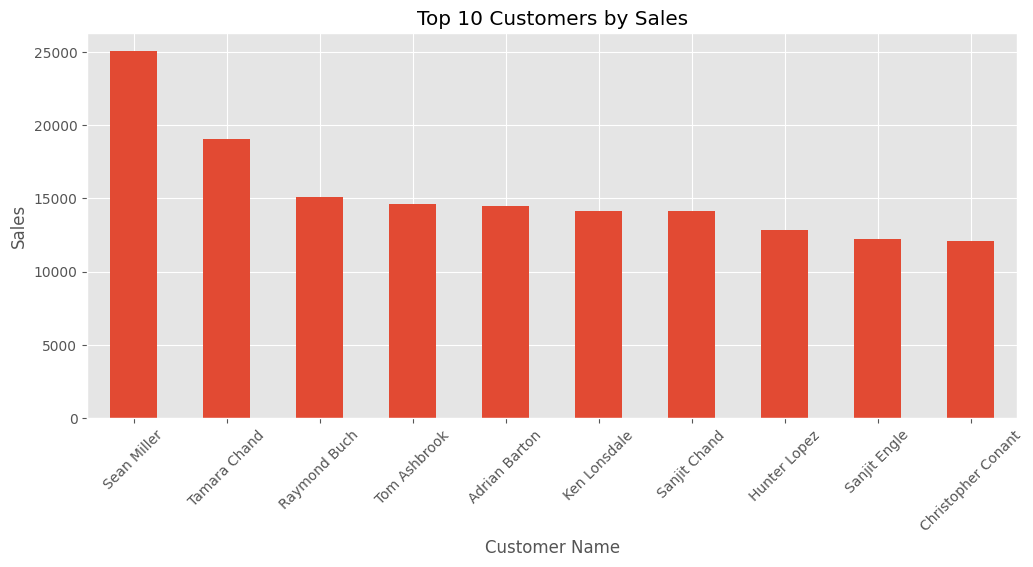

In [37]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer Name')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.savefig('../screenshots/top_customers.png')

plt.show()

## 2. Profit by Region

The analysis revealed differences in profitability across regions.

Some regions generated strong profits while others underperformed, indicating potential operational or pricing inefficiencies.

Regional analysis helps businesses optimize marketing, logistics, and inventory strategies.

## 3. Top Customers

A small group of customers contributed a large portion of total sales.

This suggests that customer retention strategies and loyalty programs could significantly impact future revenue growth.

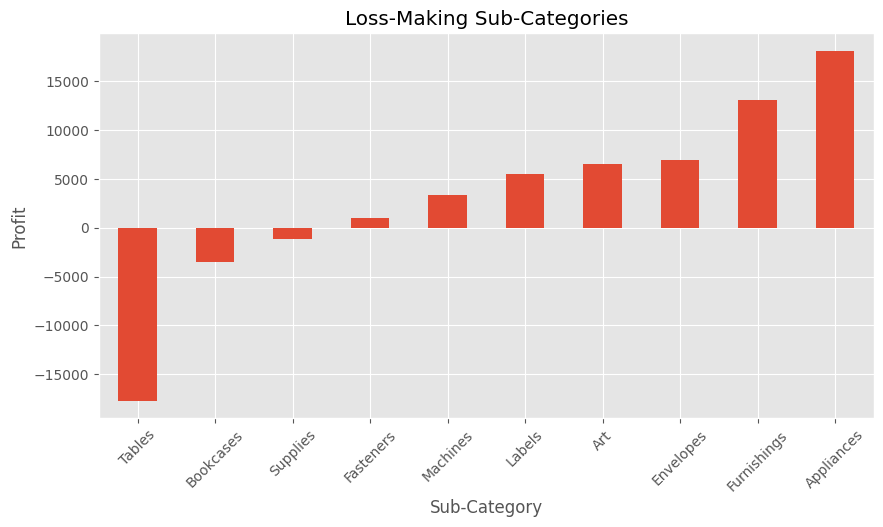

In [38]:
loss_subcategories = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(10)

plt.figure(figsize=(10,5))

loss_subcategories.plot(kind='bar')

plt.title('Loss-Making Sub-Categories')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.savefig('../screenshots/loss_subcategories.png')

plt.show()

## 4. Loss-Making Sub-Categories

Certain product sub-categories generated negative profits.

This may be caused by:
- excessive discounts
- high shipping costs
- low pricing margins

Businesses should review pricing and operational costs for these products.

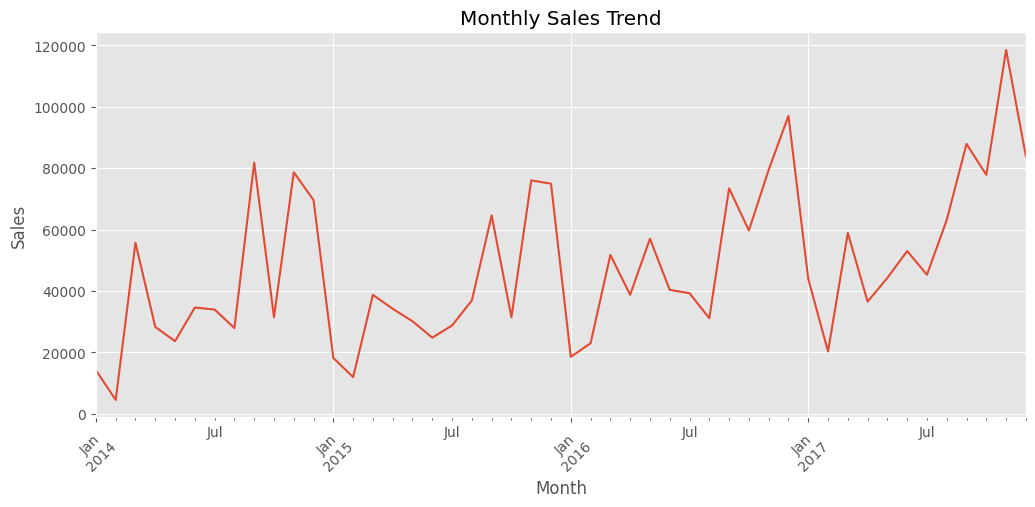

In [39]:
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.savefig('../screenshots/monthly_sales_trend.png')

plt.show()

## 5. Monthly Sales Trend

Monthly sales trends showed fluctuations over time.

Trend analysis helps businesses:
- identify seasonal demand
- forecast future sales
- improve inventory planning
- optimize promotional campaigns